# 06 - CMO rayfield measurement and optical model selection

This notebook isolates the model-selection workflow that was introduced at the
end of notebook 04 and applies it to a Common Main Objective (CMO) stereo
prototype.

The workflow is deliberately two-stage:

1. generate a CMO stereo rayfield with the physics implemented in
   `stereocomplex.physics`;
2. identify a generic Zernike rayfield `(O(u,v), d(u,v))` from the generated
   rays;
3. fit several physical hypotheses to the measured Zernike rayfield;
4. select the model that best explains the measured rayfield in ray space.

The important point is the separation of roles:

> The 2D/ray observations measure the rayfield; the rayfield is then used to
> identify and compare optical models.

In this notebook the CMO generator, the CMO fitting candidate, Brown-Conrady
distortion, vignetting, sensor warp, and ray aberrations all come from
`stereocomplex.physics`. There is no second implementation of the optical
model hidden in the generator.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import least_squares

from stereocomplex.physics import (
    BrownConrady,
    CMOChannelRayField,
    CMOChannelSpec,
    CMOIntrinsics,
    CMOPolynomialChannelModel,
    CMOPlaneTargetSpec,
    CMOStereoSpec,
    CentralBrownConradyModel,
    CentralPinholeModel,
    PhysicalModelSpec,
    PinholeParallelPlateModel,
    PolynomialRayAberration,
    SensorWarp,
    Vignetting,
    cmo_polynomial_channel_parameters_from_spec,
    fit_cmo_stereo_model_and_poses_from_zernike_rayfields,
    generate_cmo_plane_dataset,
    project_cmo_target_corners,
    rayfield_two_plane_residuals,
    render_cmo_channel_image,
    select_physical_model_from_rayfield,
)
from stereocomplex.physics.cmo import pose_from_euler_xyz
from stereocomplex.rayfields import (
    ZernikeOriginFieldConfig,
    ZernikeRayField,
    ZernikeRayFieldCoefficients,
)


def find_repo_root(start: Path) -> Path:
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / "pyproject.toml").exists() and (path / "src" / "stereocomplex").exists():
            return path
    raise RuntimeError("Could not find the StereoComplex repository root")


ROOT = find_repo_root(Path.cwd())
ASSET_DIR = ROOT / "docs" / "assets" / "cmo_model_selection"
ASSET_DIR.mkdir(parents=True, exist_ok=True)
print(f"Repository root: {ROOT}")
print(f"Assets: {ASSET_DIR}")


def show_or_close(fig) -> None:
    if "ipykernel" in sys.modules:
        plt.show()
    else:
        plt.close(fig)

Repository root: /home/jeff/StereoComplex
Assets: /home/jeff/StereoComplex/docs/assets/cmo_model_selection


## 1. Build a synthetic CMO stereo model

The CMO model has:

- one common polynomial ray aberration shared by both channels;
- left/right differential aberrations;
- per-channel Brown-Conrady distortion;
- per-channel sensor warp and vignetting;
- two effective sub-pupil origins.

The model-selection step below fits each channel independently. The fitted CMO
candidate therefore estimates the **effective** channel model: origin,
Brown-Conrady terms, and the sum of common plus differential aberrations.

In [2]:
IMAGE_SIZE = (320, 240)
intr = CMOIntrinsics(
    width=IMAGE_SIZE[0],
    height=IMAGE_SIZE[1],
    fx=310.0,
    fy=310.0,
    cx=(IMAGE_SIZE[0] - 1) / 2.0,
    cy=(IMAGE_SIZE[1] - 1) / 2.0,
)

common = PolynomialRayAberration(
    coeff_x={"x2": +2.0e-3, "y2": -1.5e-3},
    coeff_y={"xy": +1.0e-3},
)
left_diff = PolynomialRayAberration(
    coeff_x={"x": +8.0e-4},
    coeff_y={"y": -6.0e-4},
)
right_diff = PolynomialRayAberration(
    coeff_x={"x": -8.0e-4},
    coeff_y={"y": +6.0e-4},
)

cmo = CMOStereoSpec(
    left=CMOChannelSpec(
        name="left",
        intrinsics=intr,
        origin_world_mm=(-4.0, 0.15, 0.0),
        distortion=BrownConrady(k1=-0.08, k2=0.018, p1=2.0e-4, p2=-1.0e-4),
        differential_aberration=left_diff,
        sensor_warp=SensorWarp(du_coeff_px={"xy": 0.18}, dv_coeff_px={"x2": -0.12}),
        vignetting=Vignetting(strength=0.18, floor=0.55, x_shift=-0.05),
    ),
    right=CMOChannelSpec(
        name="right",
        intrinsics=intr,
        origin_world_mm=(+4.0, -0.10, 0.0),
        distortion=BrownConrady(k1=-0.072, k2=0.015, p1=-2.0e-4, p2=1.0e-4),
        differential_aberration=right_diff,
        sensor_warp=SensorWarp(du_coeff_px={"xy": -0.15}, dv_coeff_px={"y2": 0.10}),
        vignetting=Vignetting(strength=0.18, floor=0.55, x_shift=+0.05),
    ),
    common_aberration=common,
)
K = intr.as_K()

left_true = CMOChannelRayField(cmo.left, cmo.common_aberration, name="left_cmo_oracle")
right_true = CMOChannelRayField(cmo.right, cmo.common_aberration, name="right_cmo_oracle")

print("CMO channel origins")
print(f"  left : {cmo.left.origin}")
print(f"  right: {cmo.right.origin}")

CMO channel origins
  left : [-4.    0.15  0.  ]
  right: [ 4.  -0.1  0. ]


## 2. Render a small CMO calibration scene

The rendered image is not used for the fits below. It is included to show that
the same physics object can generate images and rayfields. The renderer uses:

$$
\text{pixel}\rightarrow\text{CMO ray}\rightarrow\text{target plane}
\rightarrow\text{texture sample}.
$$

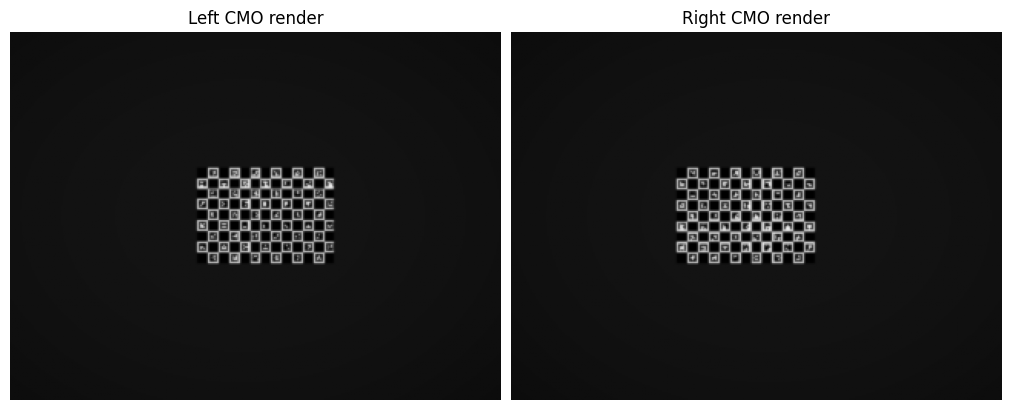

In [3]:
target = CMOPlaneTargetSpec(
    squares_x=13,
    squares_y=9,
    square_size_mm=4.0,
    pixels_per_square=36,
    pattern="charuco",
)
pose = pose_from_euler_xyz(0.0, 0.0, 0.0, (0.0, 0.0, 180.0))
texture = target.make_texture_u8()

left_img = render_cmo_channel_image(
    cmo,
    cmo.left,
    target,
    pose,
    texture,
    blur_sigma_px=0.6,
    noise_std_gray=0.0,
    rng=np.random.default_rng(3),
)
right_img = render_cmo_channel_image(
    cmo,
    cmo.right,
    target,
    pose,
    texture,
    blur_sigma_px=0.6,
    noise_std_gray=0.0,
    rng=np.random.default_rng(4),
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
axes[0].imshow(left_img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Left CMO render")
axes[1].imshow(right_img, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Right CMO render")
for ax in axes:
    ax.axis("off")
fig.savefig(ASSET_DIR / "cmo_rendered_pair.png", dpi=160)
show_or_close(fig)

We can also write a tiny dataset with the same physics. This keeps the example
concrete for later image-based front-ends, while the rest of the notebook stays
focused on ray-space model selection.

In [4]:
dataset_dir = ASSET_DIR / "generated_cmo_dataset"
generate_cmo_plane_dataset(
    out_dir=dataset_dir,
    cmo=cmo,
    target=target,
    poses=[pose],
    blur_sigma_px=0.6,
    noise_std_gray=0.0,
    seed=11,
)
print(f"Wrote {dataset_dir.relative_to(ROOT)}")

Wrote docs/assets/cmo_model_selection/generated_cmo_dataset


## 3. Measure generic Zernike rayfields O(u,v), d(u,v)

In a real workflow, the rayfield would come from images, detections, and BA. In
this controlled notebook we isolate the model-selection question by fitting a
generic Zernike rayfield directly to the generated CMO rays.

The fitted object is deliberately generic:

$$
\widehat{\mathcal R}_Z(u,v)=
\left(\widehat O(u,v), \widehat d(u,v)\right).
$$

It does not know that the oracle was a CMO.

In [5]:
def grid_pixels(image_size: tuple[int, int], grid_shape: tuple[int, int]) -> np.ndarray:
    width, height = image_size
    nx, ny = grid_shape
    u = np.linspace(0.0, width - 1.0, nx)
    v = np.linspace(0.0, height - 1.0, ny)
    uu, vv = np.meshgrid(u, v)
    return np.column_stack([uu.reshape(-1), vv.reshape(-1)])


def residual_norms(residuals: np.ndarray) -> np.ndarray:
    return np.linalg.norm(np.asarray(residuals).reshape(-1, 6), axis=1)


def fit_zernike_rayfield_to_target(
    target_field,
    K: np.ndarray,
    image_size: tuple[int, int],
    max_order: int = 3,
    grid_shape: tuple[int, int] = (11, 9),
    z_planes: tuple[float, float] = (80.0, 260.0),
) -> tuple[ZernikeRayField, np.ndarray, object]:
    config = ZernikeOriginFieldConfig(image_size=image_size, max_order=max_order)
    template = ZernikeRayField(K, config)
    n_terms = len(template.modes)
    pixels = grid_pixels(image_size, grid_shape)
    x0 = np.zeros(2 * n_terms * 3, dtype=np.float64)

    def field_from_vector(x: np.ndarray) -> ZernikeRayField:
        arr = np.asarray(x, dtype=np.float64)
        origin = arr[: n_terms * 3].reshape(n_terms, 3)
        direction = arr[n_terms * 3 :].reshape(n_terms, 3)
        return ZernikeRayField(K, config, ZernikeRayFieldCoefficients(origin, direction))

    def objective(x: np.ndarray) -> np.ndarray:
        field = field_from_vector(x)
        data = rayfield_two_plane_residuals(target_field, field, pixels, z_planes=z_planes)
        # Weakly damp the direction field; otherwise a flexible model can trade
        # equivalent line changes between origin and direction coefficients.
        direction = x[n_terms * 3 :]
        return np.r_[data, 1.0e-3 * direction]

    result = least_squares(
        objective,
        x0=x0,
        loss="huber",
        f_scale=1.0,
        max_nfev=400,
        xtol=1e-10,
        ftol=1e-10,
        gtol=1e-10,
    )
    return field_from_vector(result.x), pixels, result


left_zernike, support_left, left_fit = fit_zernike_rayfield_to_target(left_true, K, IMAGE_SIZE)
right_zernike, support_right, right_fit = fit_zernike_rayfield_to_target(right_true, K, IMAGE_SIZE)

for name, true_field, z_field, fit in [
    ("left", left_true, left_zernike, left_fit),
    ("right", right_true, right_zernike, right_fit),
]:
    residuals = rayfield_two_plane_residuals(true_field, z_field, grid_pixels(IMAGE_SIZE, (17, 13)))
    norms = residual_norms(residuals)
    print(f"{name} Zernike O+d fit")
    print(f"  success       : {fit.success}")
    print(f"  n coeffs      : {z_field.origin_coeffs.size + z_field.direction_coeffs.size}")
    print(f"  ray RMS       : {np.sqrt(np.mean(norms**2)):.4f} mm")
    print(f"  ray median    : {np.median(norms):.4f} mm")
    print(f"  ray P95       : {np.percentile(norms, 95):.4f} mm")

left Zernike O+d fit
  success       : True
  n coeffs      : 60
  ray RMS       : 0.1149 mm
  ray median    : 0.0938 mm
  ray P95       : 0.1712 mm
right Zernike O+d fit
  success       : True
  n coeffs      : 60
  ray RMS       : 0.1022 mm
  ray median    : 0.0847 mm
  ray P95       : 0.1531 mm


## 4. Define physical candidates

The measured Zernike rayfield is the target. The physical candidates are
hypotheses:

- central pinhole;
- central Brown-Conrady;
- pinhole plus inclined parallel plate;
- effective CMO polynomial channel.

The CMO candidate has more parameters, so BIC penalizes it. It should still win
if it explains the measured rayfield substantially better.

In [6]:
def cmo_candidate_specs(image_size: tuple[int, int]) -> list[PhysicalModelSpec]:
    terms = CMOPolynomialChannelModel.default_terms()
    cmo_initial = np.zeros(7 + 2 * len(terms), dtype=np.float64)
    cmo_bounds = (
        np.r_[[-12.0, -12.0, -1.0, -1.0, -0.1, -0.1, -1.0], -0.05 * np.ones(2 * len(terms))],
        np.r_[[+12.0, +12.0, +1.0, +1.0, +0.1, +0.1, +1.0], +0.05 * np.ones(2 * len(terms))],
    )
    return [
        PhysicalModelSpec("central_pinhole", CentralPinholeModel, np.zeros(0)),
        PhysicalModelSpec(
            "central_brown_conrady",
            CentralBrownConradyModel,
            np.zeros(5),
            bounds=(
                np.array([-1.0, -1.0, -0.1, -0.1, -1.0], dtype=np.float64),
                np.array([+1.0, +1.0, +0.1, +0.1, +1.0], dtype=np.float64),
            ),
        ),
        PhysicalModelSpec(
            "pinhole_parallel_plate",
            PinholeParallelPlateModel,
            np.array([0.0, 0.0, 8.0], dtype=np.float64),
            bounds=(
                np.array([-30.0, -30.0, 0.0], dtype=np.float64),
                np.array([+30.0, +30.0, 50.0], dtype=np.float64),
            ),
            model_kwargs={"eta": 1.5, "d1_mm": 80.0},
        ),
        PhysicalModelSpec(
            "cmo_polynomial_channel",
            CMOPolynomialChannelModel,
            cmo_initial,
            bounds=cmo_bounds,
            model_kwargs={"cmo_image_size": image_size, "aberration_terms": terms},
        ),
    ]


left_report = select_physical_model_from_rayfield(
    target_field=left_zernike,
    candidate_specs=cmo_candidate_specs(IMAGE_SIZE),
    K=K,
    image_size=IMAGE_SIZE,
    grid_shape=(13, 11),
    support_pixels=support_left,
    full_grid_weight=0.35,
    max_nfev=500,
)
right_report = select_physical_model_from_rayfield(
    target_field=right_zernike,
    candidate_specs=cmo_candidate_specs(IMAGE_SIZE),
    K=K,
    image_size=IMAGE_SIZE,
    grid_shape=(13, 11),
    support_pixels=support_right,
    full_grid_weight=0.35,
    max_nfev=500,
)


def print_report(label: str, report) -> None:
    print(label)
    print(f"  best by BIC: {report.best_by_bic}")
    print(f"  best by RMS: {report.best_by_rms}")
    for row in report.rows():
        marker = "*" if row["selected_bic"] else " "
        print(
            f"{marker} {row['model']:<26s} "
            f"p={row['parameters']:>2d} "
            f"rms={row['rms_mm']:>8.4f} "
            f"support={row['support_rms_mm']:>8.4f} "
            f"full={row['full_grid_rms_mm']:>8.4f} "
            f"BIC={row['bic']:>10.1f}"
        )


print_report("Left measured Zernike rayfield", left_report)
print()
print_report("Right measured Zernike rayfield", right_report)

Left measured Zernike rayfield
  best by BIC: cmo_polynomial_channel
  best by RMS: cmo_polynomial_channel
  central_pinhole            p= 0 rms= 10.2337 support= 10.2337 full=  9.9210 BIC=    3077.7
  central_brown_conrady      p= 5 rms=  4.7092 support=  4.7092 full=  4.7145 BIC=     864.8
  pinhole_parallel_plate     p= 3 rms= 10.3695 support= 10.3695 full= 10.0098 BIC=    3130.7
* cmo_polynomial_channel     p=17 rms=  0.0421 support=  0.0421 full=  0.0405 BIC=  -12785.9

Right measured Zernike rayfield
  best by BIC: cmo_polynomial_channel
  best by RMS: cmo_polynomial_channel
  central_pinhole            p= 0 rms=  9.4304 support=  9.4304 full=  9.1640 BIC=    2841.3
  central_brown_conrady      p= 5 rms=  4.6229 support=  4.6229 full=  4.6296 BIC=     811.3
  pinhole_parallel_plate     p= 3 rms=  9.4595 support=  9.4595 full=  9.1372 BIC=    2864.2
* cmo_polynomial_channel     p=17 rms=  0.0377 support=  0.0377 full=  0.0363 BIC=  -13105.7


## 5. Read the fitted CMO parameters

The fitted CMO candidate estimates one effective channel model. Because this
notebook fits channels independently, the recovered aberration coefficients are
the sum of common and differential channel effects.

In [7]:
def selected_params(report) -> dict[str, float]:
    by_name = {candidate.model_name: candidate for candidate in report.candidates}
    return by_name["cmo_polynomial_channel"].parameter_dict


for name, truth, params in [
    ("left", cmo.left, selected_params(left_report)),
    ("right", cmo.right, selected_params(right_report)),
]:
    print(name)
    print(f"  origin truth: {truth.origin[:2]}")
    print(f"  origin fit  : {[params['origin_x_mm'], params['origin_y_mm']]}")
    print(f"  k1 truth/fit: {truth.distortion.k1:+.5f} / {params['k1']:+.5f}")
    print(f"  k2 truth/fit: {truth.distortion.k2:+.5f} / {params['k2']:+.5f}")
    print(f"  p1 truth/fit: {truth.distortion.p1:+.5e} / {params['p1']:+.5e}")
    print(f"  p2 truth/fit: {truth.distortion.p2:+.5e} / {params['p2']:+.5e}")

left
  origin truth: [-4.    0.15]
  origin fit  : [-3.99987225486458, 0.15097271680150098]
  k1 truth/fit: -0.08000 / -0.06856
  k2 truth/fit: +0.01800 / -0.00822
  p1 truth/fit: +2.00000e-04 / +1.79818e-04
  p2 truth/fit: -1.00000e-04 / -1.24634e-04
right
  origin truth: [ 4.  -0.1]
  origin fit  : [4.000141333933451, -0.10072307215442854]
  k1 truth/fit: -0.07200 / -0.06170
  k2 truth/fit: +0.01500 / -0.00864
  p1 truth/fit: -2.00000e-04 / -2.52084e-04
  p2 truth/fit: +1.00000e-04 / +4.54833e-05


## 6. Complete CMO rayfield BA: optics and board poses

Model selection fitted each channel independently in ray space. We now run a
more coupled benchmark: optimize the left/right effective CMO parameters and
several board poses together.

This is still not a detector benchmark. The measured Zernike fields provide
the pixel-to-line observations, while synthetic ChArUco correspondences provide
the board geometry. The objective combines:

- point-to-line incidence of ChArUco corners with the fitted CMO rays;
- a ray-space anchor that keeps the fitted CMO channels close to the measured
  Zernike rayfields;
- optional pose regularization, set to zero here because the problem is
  well-constrained in this controlled case.

The purpose is to check that the CMO parameterization is not only selectable,
but also sufficiently well posed for joint optical/pose refinement once a
generic rayfield has been measured.

In [8]:
ba_poses_truth = [
    pose_from_euler_xyz(+0.00, +0.00, +0.00, (0.0, 0.0, 180.0)),
    pose_from_euler_xyz(+0.04, -0.03, +0.02, (-4.0, +2.0, 188.0)),
    pose_from_euler_xyz(-0.05, +0.05, -0.03, (+3.5, -2.5, 176.0)),
    pose_from_euler_xyz(+0.07, +0.02, +0.04, (+5.0, +1.0, 194.0)),
]

corner_ids, corner_xy = target.inner_corners_local_mm()
object_frames = []
left_pixel_frames = []
right_pixel_frames = []

for board_pose in ba_poses_truth:
    gt = project_cmo_target_corners(cmo, target, board_pose)
    object_frames.append(corner_xy[gt["corner_id"]])
    left_pixel_frames.append(gt["uv_left_px"])
    right_pixel_frames.append(gt["uv_right_px"])

pose_initials = [
    pose_from_euler_xyz(+0.01, -0.01, +0.005, (+0.2, -0.1, 180.3)),
    pose_from_euler_xyz(+0.05, -0.04, +0.025, (-3.8, +1.8, 188.2)),
    pose_from_euler_xyz(-0.04, +0.04, -0.020, (+3.7, -2.7, 176.2)),
    pose_from_euler_xyz(+0.08, +0.01, +0.035, (+5.2, +0.8, 194.2)),
]

terms = CMOPolynomialChannelModel.default_terms()
left_initial = np.array(
    [
        selected_params(left_report)[key]
        for key in [
            "origin_x_mm",
            "origin_y_mm",
            "k1",
            "k2",
            "p1",
            "p2",
            "k3",
        ]
    ]
    + [selected_params(left_report)[f"aberr_x_{name}"] for name in terms]
    + [selected_params(left_report)[f"aberr_y_{name}"] for name in terms],
    dtype=np.float64,
)
right_initial = np.array(
    [
        selected_params(right_report)[key]
        for key in [
            "origin_x_mm",
            "origin_y_mm",
            "k1",
            "k2",
            "p1",
            "p2",
            "k3",
        ]
    ]
    + [selected_params(right_report)[f"aberr_x_{name}"] for name in terms]
    + [selected_params(right_report)[f"aberr_y_{name}"] for name in terms],
    dtype=np.float64,
)

ba_result = fit_cmo_stereo_model_and_poses_from_zernike_rayfields(
    left_field=left_zernike,
    right_field=right_zernike,
    K=K,
    image_size=IMAGE_SIZE,
    object_points=object_frames,
    left_pixels=left_pixel_frames,
    right_pixels=right_pixel_frames,
    pose_initials=pose_initials,
    initial_left_parameters=left_initial,
    initial_right_parameters=right_initial,
    aberration_terms=terms,
    rayfield_weight=0.35,
    pose_regularization=0.0,
    max_nfev=500,
)


def pose_errors(fitted, truth):
    t_err = []
    r_err = []
    for pose_fit, pose_true in zip(fitted, truth, strict=True):
        t_err.append(np.linalg.norm(pose_fit.t - pose_true.t))
        # angle of relative rotation in degrees
        cos_angle = np.clip((np.trace(pose_fit.R @ pose_true.R.T) - 1.0) / 2.0, -1.0, 1.0)
        r_err.append(np.degrees(np.arccos(cos_angle)))
    return np.asarray(t_err), np.asarray(r_err)


t_err, r_err = pose_errors(ba_result.poses, ba_poses_truth)
left_truth_params = cmo_polynomial_channel_parameters_from_spec(cmo.left, cmo.common_aberration, terms)
right_truth_params = cmo_polynomial_channel_parameters_from_spec(cmo.right, cmo.common_aberration, terms)

print("Complete CMO rayfield BA")
print(f"  success              : {ba_result.success}")
print(f"  observations          : {ba_result.n_observations}")
print(f"  incidence RMS         : {ba_result.incidence_rms_mm:.5f} mm")
print(f"  incidence P95         : {ba_result.incidence_p95_mm:.5f} mm")
print(f"  left rayfield RMS     : {ba_result.left_rayfield_rms_mm:.5f} mm")
print(f"  right rayfield RMS    : {ba_result.right_rayfield_rms_mm:.5f} mm")
print(f"  pose translation RMS  : {np.sqrt(np.mean(t_err**2)):.5f} mm")
print(f"  pose rotation RMS     : {np.sqrt(np.mean(r_err**2)):.5f} deg")
print(
    "  left origin truth/BA  : "
    f"{cmo.left.origin[:2]} / {[ba_result.left_model.origin_x_mm, ba_result.left_model.origin_y_mm]}"
)
print(
    "  right origin truth/BA : "
    f"{cmo.right.origin[:2]} / {[ba_result.right_model.origin_x_mm, ba_result.right_model.origin_y_mm]}"
)

Complete CMO rayfield BA
  success              : True
  observations          : 384
  incidence RMS         : 0.00040 mm
  incidence P95         : 0.00074 mm
  left rayfield RMS     : 0.01393 mm
  right rayfield RMS    : 0.01244 mm
  pose translation RMS  : 0.05071 mm
  pose rotation RMS     : 0.00759 deg
  left origin truth/BA  : [-4.    0.15] / [-4.001187009286871, 0.149629694736241]
  right origin truth/BA : [ 4.  -0.1] / [4.000243454336396, -0.0998557432892648]


Individual Brown and polynomial coefficients are partly correlated in this
compact CMO channel model. The stable engineering checks are therefore:
origin recovery, pose recovery, incidence residual, and ray-space residual to
the measured Zernike fields. The parameter vectors are still reported for
auditability.

In [9]:
left_param_error = ba_result.left_model.parameter_vector() - left_truth_params
right_param_error = ba_result.right_model.parameter_vector() - right_truth_params
print("CMO BA parameter-vector errors")
print(f"  left  L2: {np.linalg.norm(left_param_error):.5e}")
print(f"  right L2: {np.linalg.norm(right_param_error):.5e}")

CMO BA parameter-vector errors
  left  L2: 1.00465e+00
  right L2: 8.16038e-01


## 7. Visualize model selection

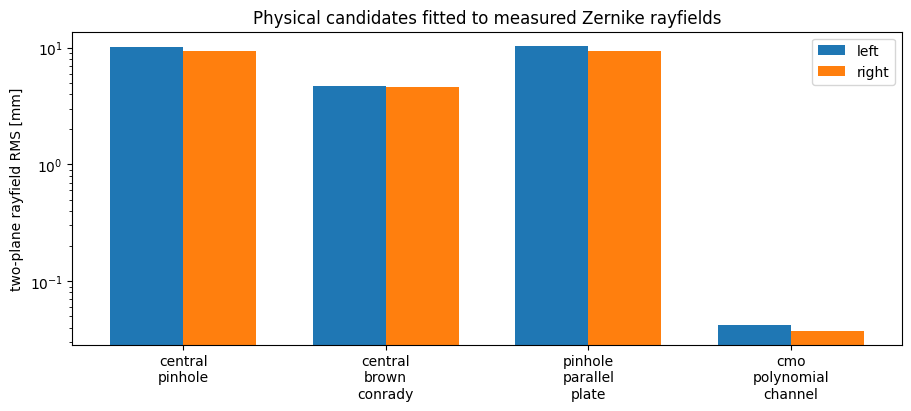

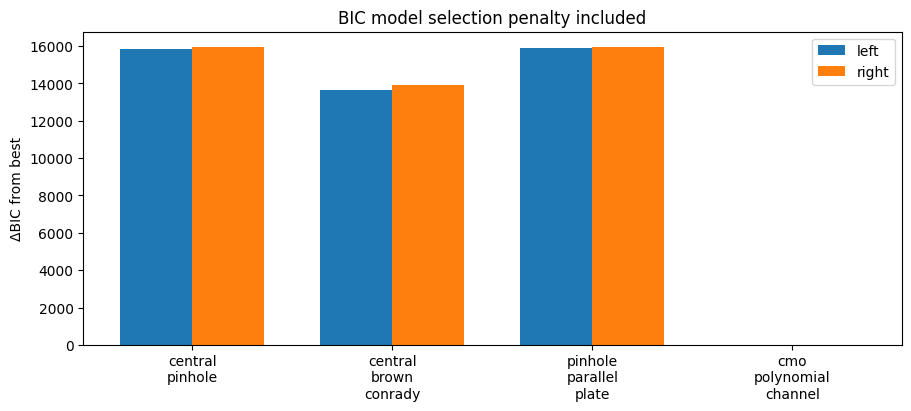

In [10]:
def rows_to_arrays(report):
    rows = report.rows()
    labels = [row["model"].replace("_", "\n") for row in rows]
    rms = np.array([row["rms_mm"] for row in rows], dtype=float)
    bic = np.array([row["bic"] for row in rows], dtype=float)
    return labels, rms, bic


labels, left_rms, left_bic = rows_to_arrays(left_report)
_, right_rms, right_bic = rows_to_arrays(right_report)
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
width = 0.36
ax.bar(x - width / 2, left_rms, width, label="left")
ax.bar(x + width / 2, right_rms, width, label="right")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("two-plane rayfield RMS [mm]")
ax.set_title("Physical candidates fitted to measured Zernike rayfields")
ax.set_yscale("log")
ax.legend()
fig.savefig(ASSET_DIR / "cmo_model_selection_rms.png", dpi=160)
show_or_close(fig)

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
left_delta = left_bic - np.min(left_bic)
right_delta = right_bic - np.min(right_bic)
ax.bar(x - width / 2, left_delta, width, label="left")
ax.bar(x + width / 2, right_delta, width, label="right")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("ΔBIC from best")
ax.set_title("BIC model selection penalty included")
ax.legend()
fig.savefig(ASSET_DIR / "cmo_model_selection_bic.png", dpi=160)
show_or_close(fig)

## 8. Save a compact JSON report

In [11]:
summary = {
    "left": {
        "best_by_bic": left_report.best_by_bic,
        "rows": left_report.rows(),
        "cmo_parameters": selected_params(left_report),
    },
    "right": {
        "best_by_bic": right_report.best_by_bic,
        "rows": right_report.rows(),
        "cmo_parameters": selected_params(right_report),
    },
    "complete_cmo_ba": {
        "success": ba_result.success,
        "n_observations": ba_result.n_observations,
        "incidence_rms_mm": ba_result.incidence_rms_mm,
        "incidence_p95_mm": ba_result.incidence_p95_mm,
        "left_rayfield_rms_mm": ba_result.left_rayfield_rms_mm,
        "right_rayfield_rms_mm": ba_result.right_rayfield_rms_mm,
        "pose_translation_rms_mm": float(np.sqrt(np.mean(t_err**2))),
        "pose_rotation_rms_deg": float(np.sqrt(np.mean(r_err**2))),
        "left_origin_error_mm": (
            np.array([ba_result.left_model.origin_x_mm, ba_result.left_model.origin_y_mm])
            - cmo.left.origin[:2]
        ).tolist(),
        "right_origin_error_mm": (
            np.array([ba_result.right_model.origin_x_mm, ba_result.right_model.origin_y_mm])
            - cmo.right.origin[:2]
        ).tolist(),
        "left_parameter_l2": float(np.linalg.norm(left_param_error)),
        "right_parameter_l2": float(np.linalg.norm(right_param_error)),
    },
}
(ASSET_DIR / "cmo_model_selection_summary.json").write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)
print(json.dumps(summary["left"]["rows"], indent=2))

[
  {
    "model": "central_pinhole",
    "parameters": 0,
    "rms_mm": 10.233669526429711,
    "support_rms_mm": 10.233669526429711,
    "full_grid_rms_mm": 9.920953397759792,
    "bic": 3077.690757694085,
    "aic": 3077.690757694085,
    "selected_bic": false
  },
  {
    "model": "central_brown_conrady",
    "parameters": 5,
    "rms_mm": 4.7091553790689655,
    "support_rms_mm": 4.7091553790689655,
    "full_grid_rms_mm": 4.7144974774037305,
    "bic": 864.8169342609709,
    "aic": 847.3722456301875,
    "selected_bic": false
  },
  {
    "model": "pinhole_parallel_plate",
    "parameters": 3,
    "rms_mm": 10.36947726515932,
    "support_rms_mm": 10.36947726515932,
    "full_grid_rms_mm": 10.009757135141152,
    "bic": 3130.6796905728324,
    "aic": 3120.2128773943623,
    "selected_bic": false
  },
  {
    "model": "cmo_polynomial_channel",
    "parameters": 17,
    "rms_mm": 0.04208799737821682,
    "support_rms_mm": 0.04208799737821682,
    "full_grid_rms_mm": 0.0404771336240

## 9. Interpretation

The CMO candidate is not selected because the notebook tells the selector that
the oracle is a CMO. The selector only sees the measured Zernike rayfield and
ray-space residuals. Central pinhole and central Brown-Conrady can bend
directions, but they cannot represent a shifted effective sub-pupil origin.
The inclined-plate model can create non-central rays, but its geometry is the
wrong physical family for this CMO oracle.

The CMO polynomial channel wins when its lower residual compensates for its
larger parameter count in BIC. That is the intended scientific message:

> Measure the rayfield first; explain the optics second.